In [2]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix

In [3]:

# Load test data
test_data = pd.read_csv('dataset\sign_mnist_test.csv')
X_test = test_data.drop('label', axis=1).values.reshape(-1, 28, 28, 1) / 255.0
y_test = test_data['label'].values

model = tf.keras.models.load_model('cnn_model_03.keras')
y_pred = model.predict(X_test).argmax(axis=1)


225/225 [==============================] - 37s 161ms/step


In [4]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
encoder.fit(np.concatenate([y_pred, y_test]))

y_pred = encoder.transform(y_pred)
y_test = encoder.transform(y_test)

print("Unique labels in y_pred: ", np.unique(y_pred))
print("Unique labels in y_test before remapping: ", np.unique(y_test))

original_to_model = {
    0:0, 1:1, 2:2, 3:3, 4:4, 5:5, 6:6, 7:7, 8:8,  # A-I
    10:9, 11:10, 12:11, 13:12, 14:13, 15:14, 16:15, 17:16,  # K-R → 9-16
    18:17, 19:18, 20:19, 21:20, 22:21, 23:22, 24:23  # S-Y → 17-23
}

y_test = np.array([original_to_model[y] for y in y_test])

print("Unique labels in y_pred: ", np.unique(y_pred))
print("Unique labels in y_test after remapping: ", np.unique(y_test))

label_map = {
    0:'A', 1:'B', 2:'C', 3:'D', 4:'E', 5:'F', 6:'G', 7:'H',8:'I',
    9:'K', 10:'L', 11:'M', 12:'N', 13:'O', 14:'P', 15:'Q', 16:'R',
    17:'S', 18:'T', 19:'U', 20:'V', 21:'W', 22:'X', 23:'Y'
}


Unique labels in y_pred:  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Unique labels in y_test before remapping:  [ 0  1  2  3  4  5  6  7  8 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24]
Unique labels in y_pred:  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
Unique labels in y_test after remapping:  [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]


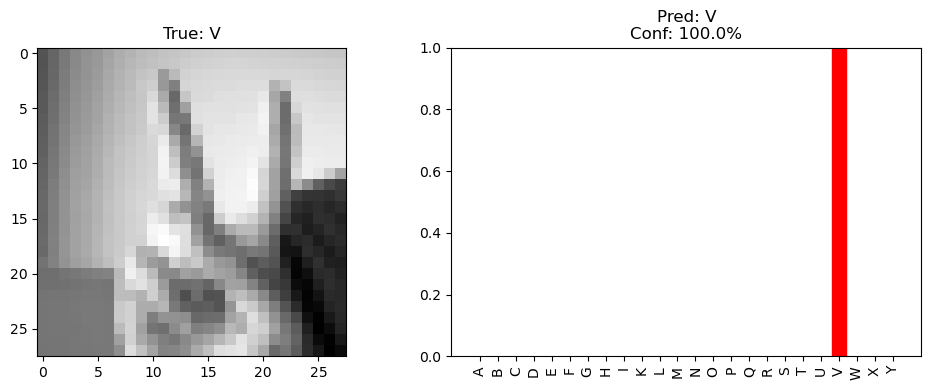

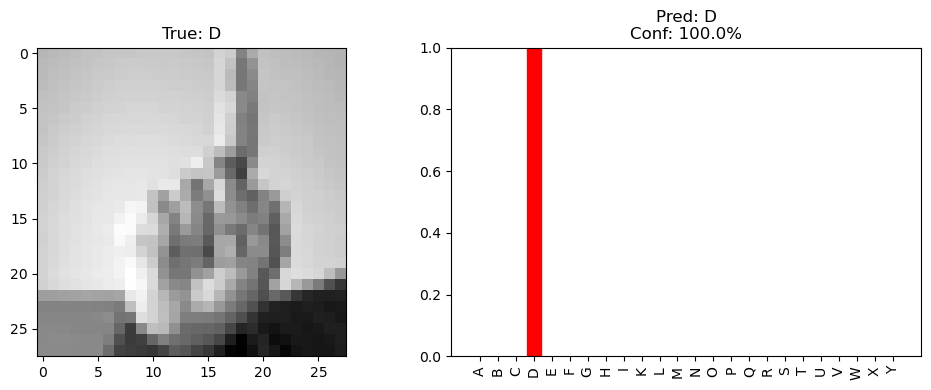

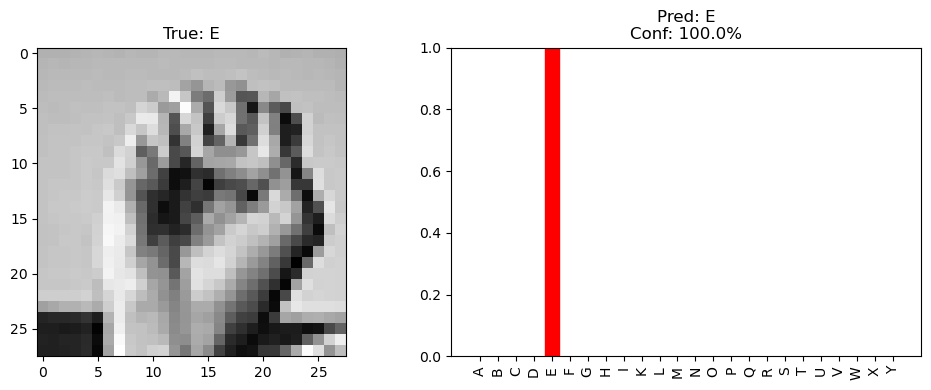

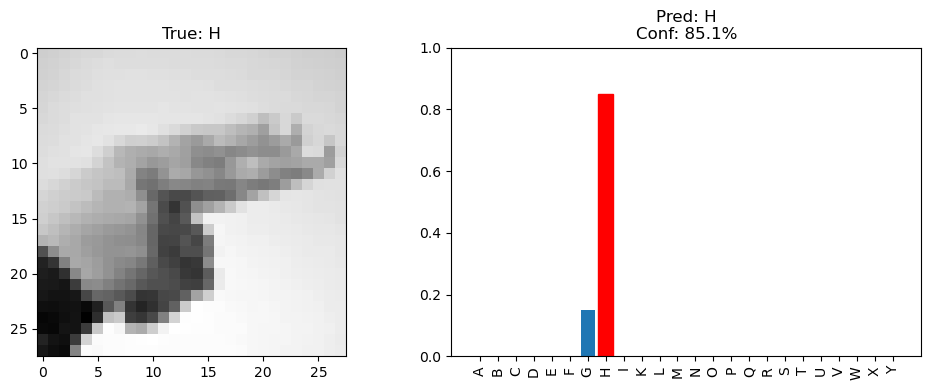

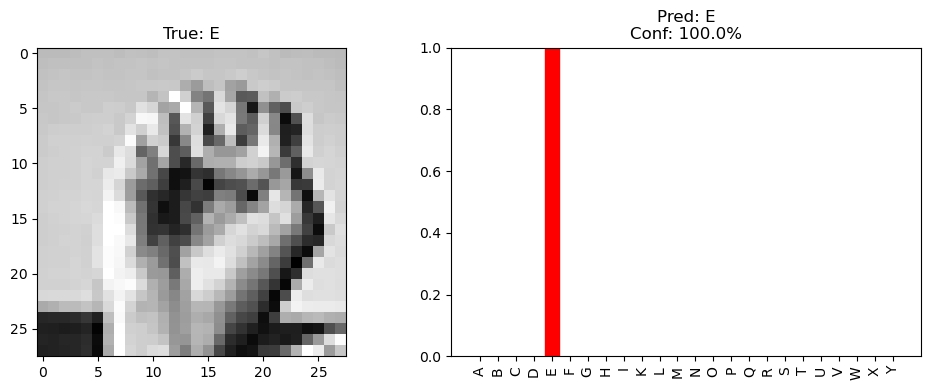

In [5]:
import random

def show_random_predictions(num_samples=5):
    random_indices = random.sample(range(len(X_test)), num_samples)

    for idx in random_indices:
        sample = X_test[idx]
        true_label = y_test[idx]

        # Predict
        pred = model.predict(np.expand_dims(sample, axis=0), verbose=0)[0]
        pred_class = np.argmax(pred)
        confidence = np.max(pred)

        # Visualization
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.imshow(sample.squeeze(), cmap='gray')
        plt.title(f"True: {label_map.get(true_label, '?')}")

        plt.subplot(1, 2, 2)
        bars = plt.bar(range(len(label_map)), pred)
        bars[pred_class].set_color('red')
        plt.xticks(range(len(label_map)), list(label_map.values()), rotation=90)
        plt.title(f"Pred: {label_map.get(pred_class, '?')}\nConf: {confidence:.1%}")
        plt.ylim(0, 1)

        plt.tight_layout()
        plt.show()

show_random_predictions(5)

              precision    recall  f1-score   support

           A       1.00      1.00      1.00       331
           B       1.00      1.00      1.00       432
           C       1.00      1.00      1.00       310
           D       0.99      1.00      1.00       245
           E       1.00      1.00      1.00       498
           F       1.00      1.00      1.00       247
           G       1.00      1.00      1.00       348
           H       1.00      1.00      1.00       436
           I       1.00      1.00      1.00       288
           K       1.00      0.99      1.00       331
           L       1.00      1.00      1.00       209
           M       1.00      1.00      1.00       394
           N       1.00      0.98      0.99       291
           O       1.00      1.00      1.00       246
           P       1.00      1.00      1.00       347
           Q       1.00      1.00      1.00       164
           R       1.00      1.00      1.00       144
           S       0.98    

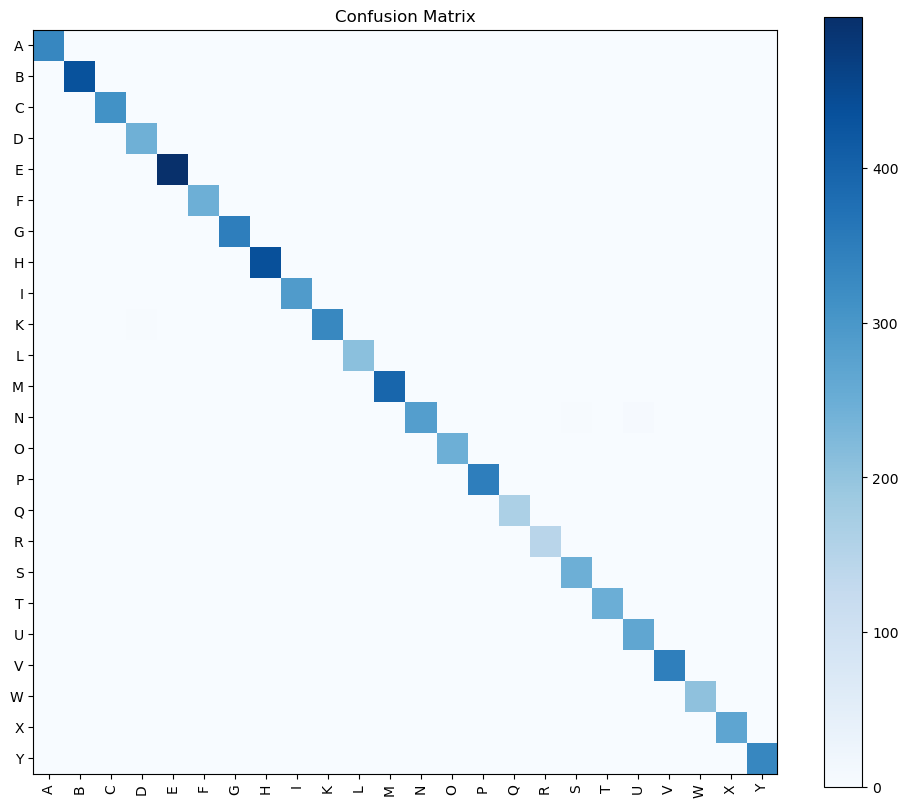

In [6]:
# Classification Report
print(classification_report(y_test, y_pred,
                          target_names=list(label_map.values())))

# Confusion Matrix
plt.figure(figsize=(12,10))
plt.imshow(confusion_matrix(y_test, y_pred), cmap='Blues')
plt.xticks(range(len(label_map)), list(label_map.values()), rotation=90)
plt.yticks(range(len(label_map)), list(label_map.values()))
plt.colorbar()
plt.title("Confusion Matrix")
plt.show()

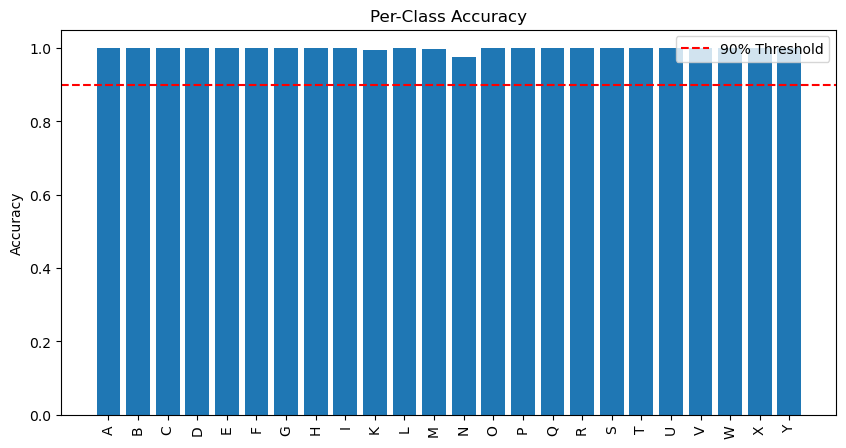

In [20]:
# Calculate accuracy per class
class_acc = {}
for letter in label_map.values():
    class_idx = list(label_map.values()).index(letter)
    mask = y_test == class_idx
    acc = (y_pred[mask] == y_test[mask]).mean()
    class_acc[letter] = acc

# Visualize
plt.figure(figsize=(10,5))
plt.bar(class_acc.keys(), class_acc.values())
plt.axhline(y=0.9, color='r', linestyle='--', label='90% Threshold')
plt.xticks(rotation=90)
plt.ylabel("Accuracy")
plt.title("Per-Class Accuracy")
plt.legend()
plt.show()

Total Errors: 10/7172 (0.1%)


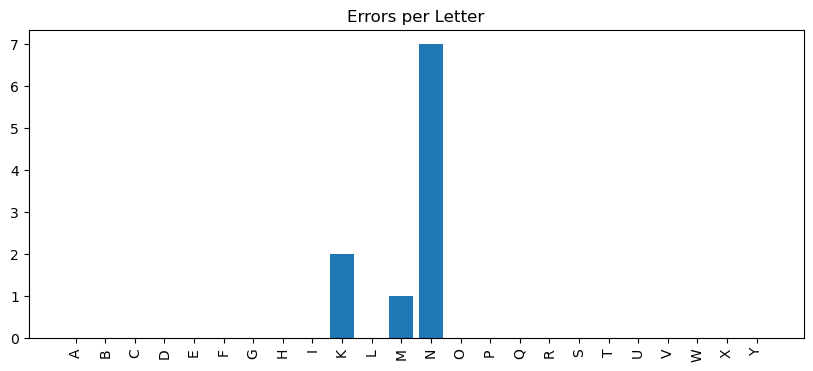

In [7]:
errors = np.where(y_pred != y_test)[0]
print(f"Total Errors: {len(errors)}/{len(y_test)} ({len(errors)/len(y_test):.1%})")

# Error distribution by class
error_counts = {}
for true_class in np.unique(y_test):
    letter = label_map[true_class]
    mask = (y_test == true_class) & (y_pred != y_test)
    error_counts[letter] = np.sum(mask)

plt.figure(figsize=(10,4))
plt.bar(error_counts.keys(), error_counts.values())
plt.xticks(rotation=90)
plt.title("Errors per Letter")
plt.show()

 Found 10 misclassified samples (0.1%)


1/1 [==============================] - 0s 232ms/step

Error Case 1:


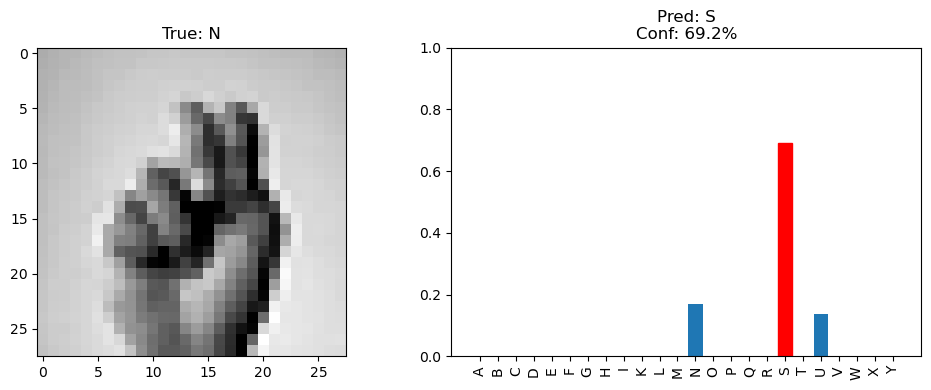

Model confidence: 69.2%

Error Case 2:


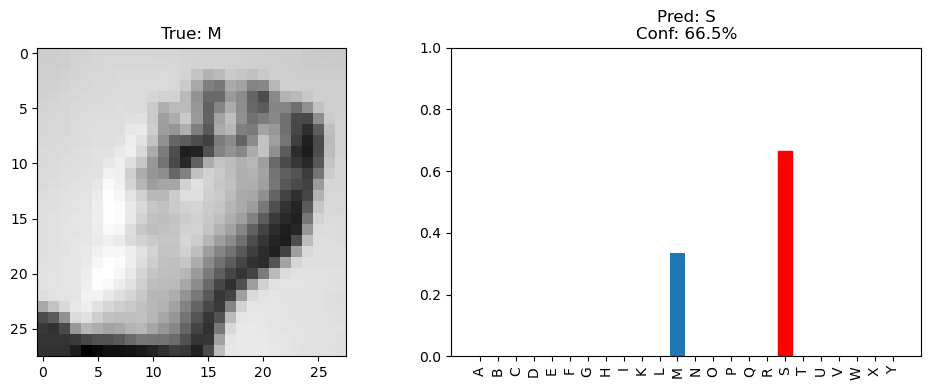

Model confidence: 66.5%

Error Case 3:


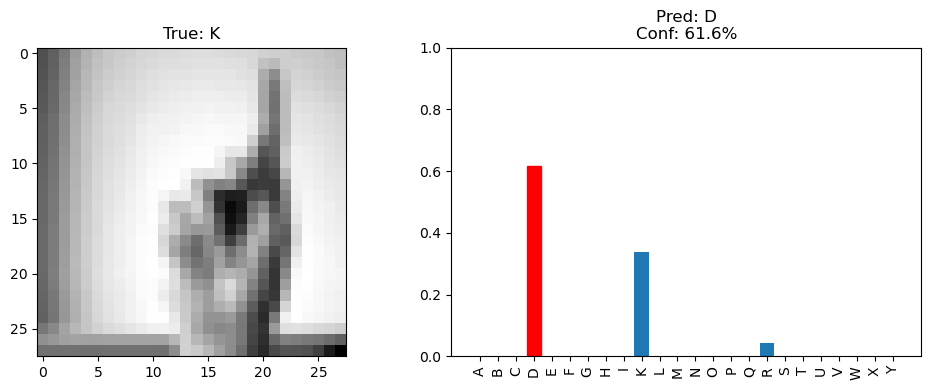

Model confidence: 61.6%

Error Case 4:


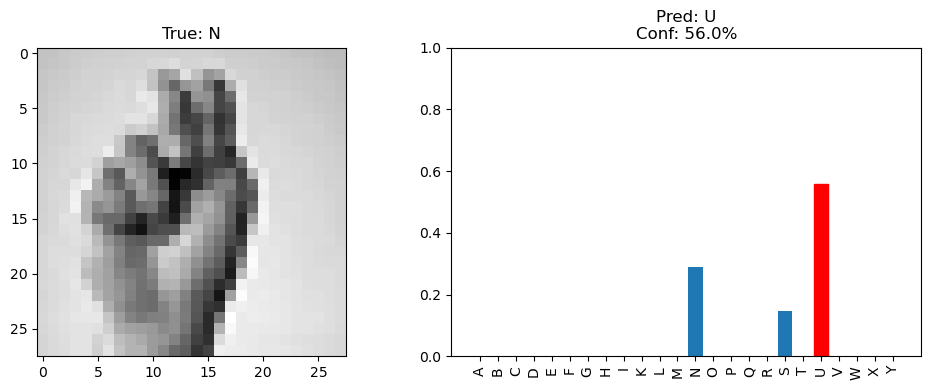

Model confidence: 56.0%

Error Case 5:


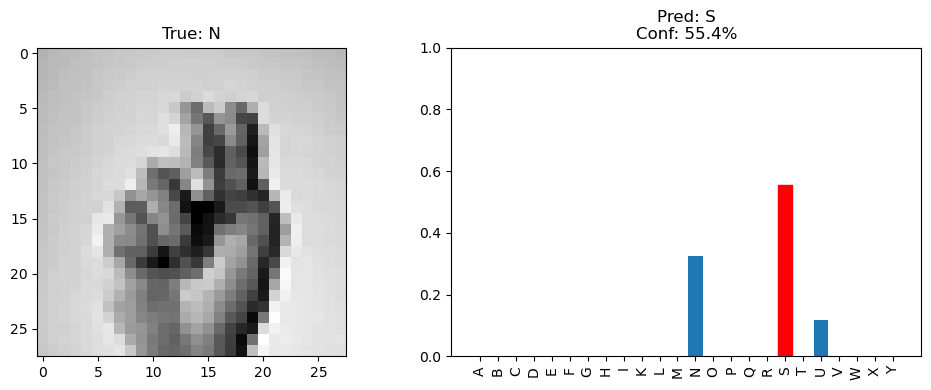

Model confidence: 55.4%

Error Case 6:


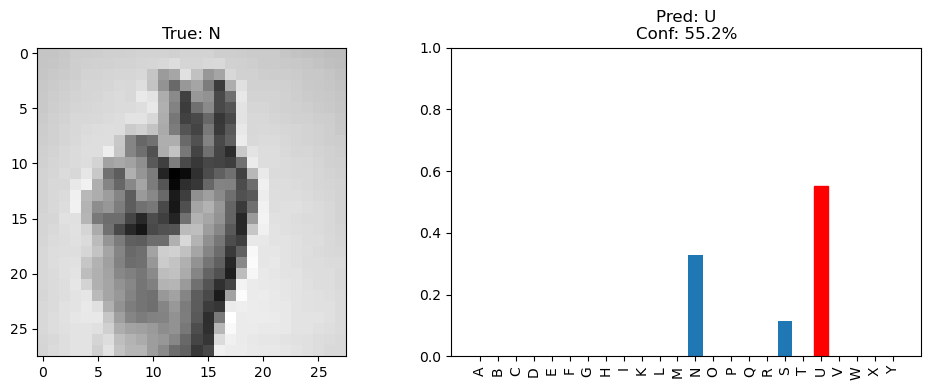

Model confidence: 55.2%

Error Case 7:


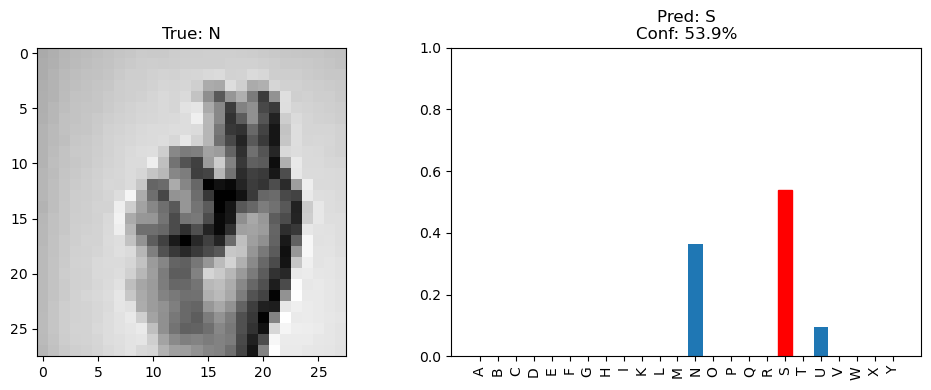

Model confidence: 53.9%

Error Case 8:


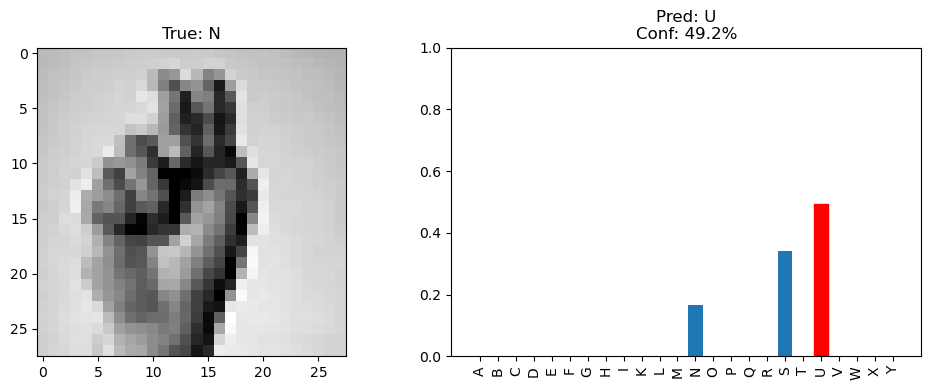

Model confidence: 49.2%

Error Case 9:


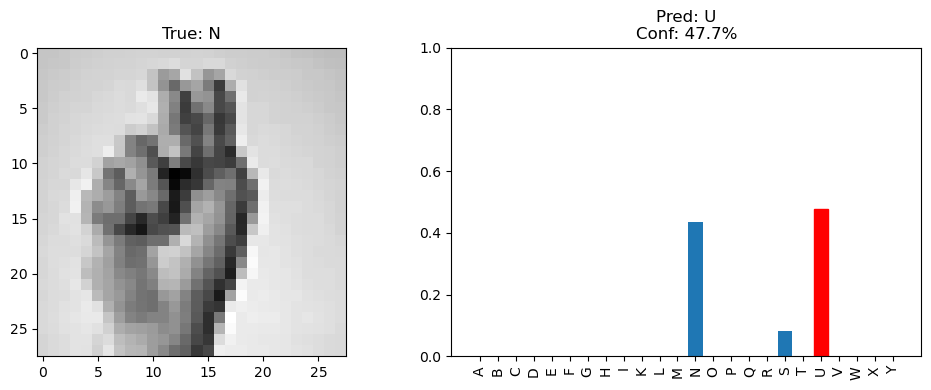

Model confidence: 47.7%

Error Case 10:


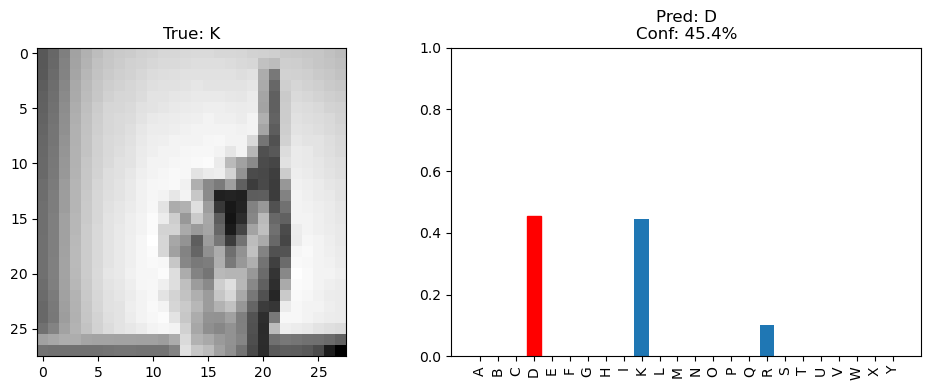

Model confidence: 45.4%


In [8]:
# Find misclassified samples
errors = np.where(y_pred != y_test)[0]
print(f" Found {len(errors)} misclassified samples ({len(errors)/len(y_test):.1%})")

# Show most confident errors
error_confidences = model.predict(X_test[errors]).max(axis=1)
top_errors = errors[np.argsort(-error_confidences)]

def show_prediction (idx):
    sample = X_test[idx]
    true_label = y_test[idx]

    # Predict
    pred = model.predict(np.expand_dims(sample, axis=0), verbose=0)[0]
    pred_class = np.argmax(pred)
    confidence = np.max(pred)

    # Visualization
    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(sample.squeeze(), cmap='gray')
    plt.title(f"True: {label_map.get(true_label, '?')}")

    plt.subplot(1, 2, 2)
    bars = plt.bar(range(len(label_map)), pred)
    bars[pred_class].set_color('red')
    plt.xticks(range(len(label_map)), list(label_map.values()), rotation=90)
    plt.title(f"Pred: {label_map.get(pred_class, '?')}\nConf: {confidence:.1%}")
    plt.ylim(0, 1)

    plt.tight_layout()
    plt.show()
    
        

for i, idx in enumerate(top_errors):
    print(f"\nError Case {i+1}:")
    
    show_prediction(idx)
    print(f"Model confidence: {error_confidences[np.argsort(-error_confidences)[i]]:.1%}")

In [9]:
from collections import Counter

# Get top 5 most confused pairs
error_pairs = Counter(zip(y_test[y_pred != y_test], y_pred[y_pred != y_test]))
top_confusions = error_pairs.most_common(5)

print("Top Confusions:")
for (true, pred), count in top_confusions:
    print(f"{label_map[true]} ⇨ {label_map[pred]}: {count} cases")

Top Confusions:
N ⇨ U: 4 cases
N ⇨ S: 3 cases
K ⇨ D: 2 cases
M ⇨ S: 1 cases
